In [71]:
# Step 1: Extract Dataset

import zipfile
import os
import cv2
import numpy as np

zip_path = "/content/archive (21).zip"
extract_path = "extracted_images"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

In [72]:
# Step 2: Load Dataset

images = []
labels = []

for root, dirs, files in os.walk(extract_path):

    for file in files:

        if file.lower().endswith((".jpg",".jpeg",".png")):

            img_path = os.path.join(root,file)

            img = cv2.imread(img_path)

            if img is not None:

                images.append(img)

                if "yes" in root.lower():
                    labels.append(1)
                else:
                    labels.append(0)

print("Total Images:",len(images))

Total Images: 506


In [73]:
# Step 3: Resize Images

X = []

for img in images:

    img = cv2.resize(img,(128,128))

    X.append(img)

X = np.array(X)

y = np.array(labels)

In [74]:
# Step 4: Normalize Images

X = X / 255.0

In [75]:
# Step 5: Split Dataset

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [76]:
#from here deep learning starts

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3, 3), activation='relu',
                 input_shape=(128, 128, 3)))

# First Pooling Layer
model.add(MaxPooling2D((2, 2)))

# Second Convolution Layer
model.add(Conv2D(64, (3, 3), activation='relu'))

# Second Pooling Layer
model.add(MaxPooling2D((2, 2)))

# Convert 2D output to 1D
model.add(Flatten())

# Hidden Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

In [77]:
# Step 7: Compile Model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [64]:
# Step 8: Train Model

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test,y_test)
)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 917ms/step - accuracy: 0.6782 - loss: 0.7270 - val_accuracy: 0.7745 - val_loss: 0.5601
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 808ms/step - accuracy: 0.8243 - loss: 0.4030 - val_accuracy: 0.8137 - val_loss: 0.4932
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8960 - loss: 0.2670 - val_accuracy: 0.8529 - val_loss: 0.4243
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 928ms/step - accuracy: 0.9604 - loss: 0.1401 - val_accuracy: 0.8922 - val_loss: 0.4447
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 921ms/step - accuracy: 0.9802 - loss: 0.0735 - val_accuracy: 0.8627 - val_loss: 0.5833
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 872ms/step - accuracy: 0.9926 - loss: 0.0290 - val_accuracy: 0.9314 - val_loss: 0.4532
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 766ms/step - accuracy: 0.9975 - loss: 0.0111 - val_accuracy: 0.9412 - val_loss: 0.4497
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 910ms/step - accuracy: 1.0000 - loss: 0.0093 - val_accurac

In [65]:
# Step 9: Test Model Accuracy

loss,accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:",accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.9412 - loss: 0.8672
Accuracy: 0.9411764740943909


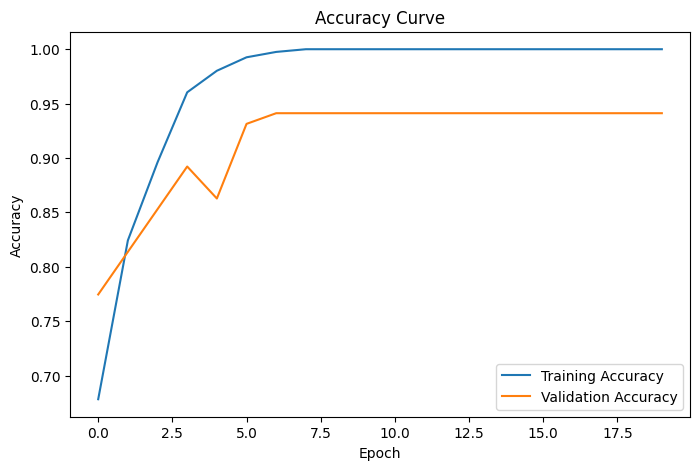

In [83]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

In [66]:
# Step 10: Upload Unseen MRI Image

from google.colab import files

uploaded = files.upload()

Saving WhatsApp Image 2026-06-12 at 2.55.19 PM.jpeg to WhatsApp Image 2026-06-12 at 2.55.19 PM (2).jpeg


In [78]:
# Step 11: Load Uploaded Image

image_name = list(uploaded.keys())[0]

img = cv2.imread(image_name)

img = cv2.resize(
    img,
    (128,128)
)

display_img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

In [79]:
# Step 12: Preprocess Uploaded Image

img = img / 255.0

img = np.expand_dims(
    img,
    axis=0
)

In [80]:
# Step 13: Predict Tumor

prediction = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


Prediction Score: 0.5032919
No Tumor


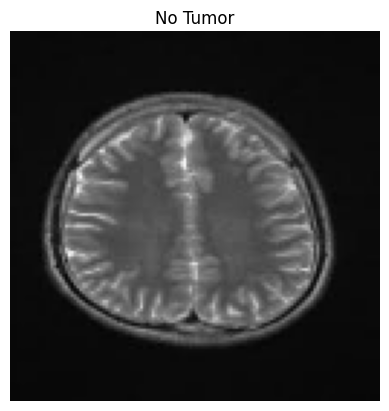

In [81]:
# Step 14: Display Result

import matplotlib.pyplot as plt

plt.imshow(display_img)
print("Prediction Score:", prediction[0][0])

if prediction[0][0] >= 0.8:
    plt.title("Tumor Detected")
    print("Tumor Detected")
else:
    plt.title("No Tumor")
    print("No Tumor")

plt.axis("off")
plt.show()